In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [41]:
f_content = ''
with open("./ucb.log", "rt") as fd:
    f_content = fd.readlines()[3:]
    
f_content = "".join(f_content)
    
data = [line.strip().split(',') for line in f_content.splitlines() if line.strip()]

column_names = ['Explore?', 'Arm', 'Reward'] + ["Arm#"+str(i+1) for i in range(10)]

df = pd.DataFrame(data, columns=column_names)
df['Arm'] = df['Arm'].astype('uint')
df['Reward'] = df['Reward'].astype('uint')

for c in df.columns[3:]:
    df[c] = df[c].astype('float')


df.head()
    

,Explore?,Arm,Reward,Arm#1,Arm#2,Arm#3,Arm#4,Arm#5,Arm#6,Arm#7,Arm#8,Arm#9,Arm#10
0,?,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,?,2,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,?,3,1,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,?,4,0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,?,5,0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [42]:
arm_pulled_count = df['Arm'].value_counts().to_dict()
print(arm_pulled_count)

print("Reward collected: ", sum(df['Reward']))
print("Agent's expected value: ", df.loc[df.shape[0] - 1])

{9: 9531, 3: 234, 10: 207, 7: 14, 6: 3, 2: 3, 1: 2, 4: 2, 5: 2, 8: 2}
Reward collected:  7435
Agent's expected value:  Explore?           ?
Arm                9
Reward             1
Arm#1            0.0
Arm#2       0.333333
Arm#3       0.974359
Arm#4            0.0
Arm#5            0.0
Arm#6       0.333333
Arm#7       0.928571
Arm#8            0.0
Arm#9       0.754171
Arm#10      0.019324
Name: 9999, dtype: object


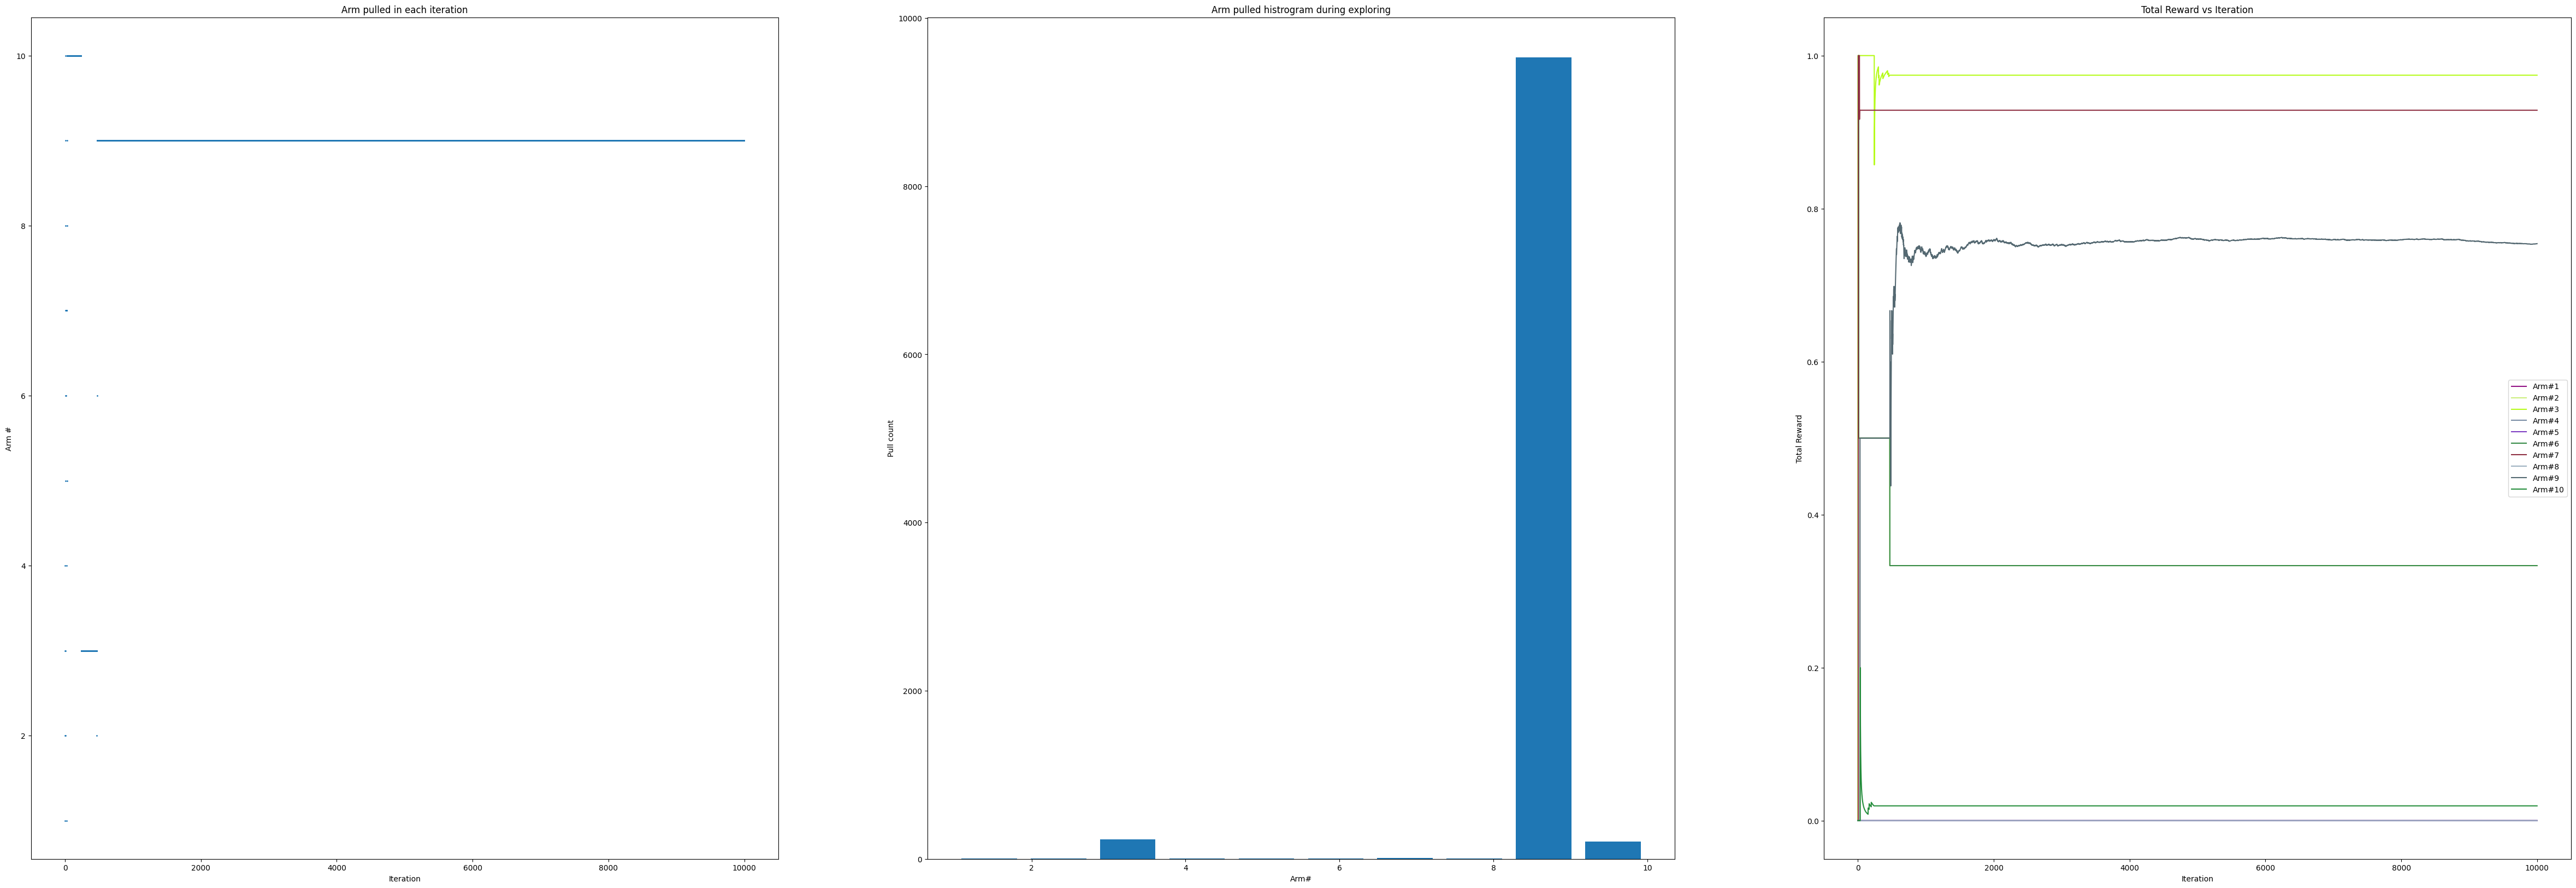

In [43]:


fig, axs = plt.subplots(1, 3, figsize=(60, 20))
axs[0].scatter(df.index.to_list(),df['Arm'], s=1)
axs[0].set_xlabel("Iteration")
axs[0].set_ylabel("Arm #")
axs[0].set_title("Arm pulled in each iteration")

axs[1].hist(df['Arm'], rwidth=0.8)
axs[1].set_xlabel("Arm#")
axs[1].set_ylabel("Pull count")
axs[1].set_title("Arm pulled histrogram during exploring")

[axs[2].plot(df.index.to_list(), df[c], color = np.random.rand(3,), label=c) for c in df.columns[3:]]
axs[2].set_xlabel("Iteration")
axs[2].set_ylabel("Total Reward")
axs[2].set_title("Total Reward vs Iteration")
axs[2].legend()

plt.show()